<a href="https://colab.research.google.com/github/Adhis-URL/Tugas_Mesin_Learning_2/blob/main/Adhi_Sukmo_Manunggal_452024611004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Data Training:", x_train.shape)
print("Data Testing:", x_test.shape)

Data Training: (50000, 32, 32, 3)
Data Testing: (10000, 32, 32, 3)


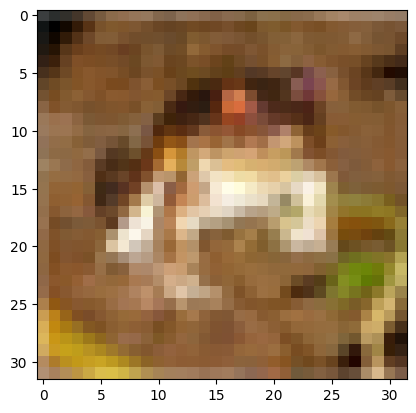

In [ ]:
plt.imshow(x_train[0])
plt.show()

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Normalisasi selesai")

Normalisasi selesai


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model siap dilatih")

Model siap dilatih


In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4681 - loss: 1.4819 - val_accuracy: 0.5567 - val_loss: 1.2481
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6025 - loss: 1.1299 - val_accuracy: 0.6263 - val_loss: 1.0755
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6518 - loss: 0.9991 - val_accuracy: 0.6533 - val_loss: 1.0052
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6862 - loss: 0.9031 - val_accuracy: 0.6720 - val_loss: 0.9458
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7138 - loss: 0.8264 - val_accuracy: 0.6771 - val_loss: 0.9535
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7394 - loss: 0.7526 - val_accuracy: 0.6900 - val_loss: 0.9040
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7593 - loss: 0.6929 - val_accuracy: 0.6966 - val_loss: 0.9022
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7791 - loss: 0.6355 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6935 - loss: 0.9570
Test Accuracy : 0.6934999823570251
Test Loss : 0.956976056098938


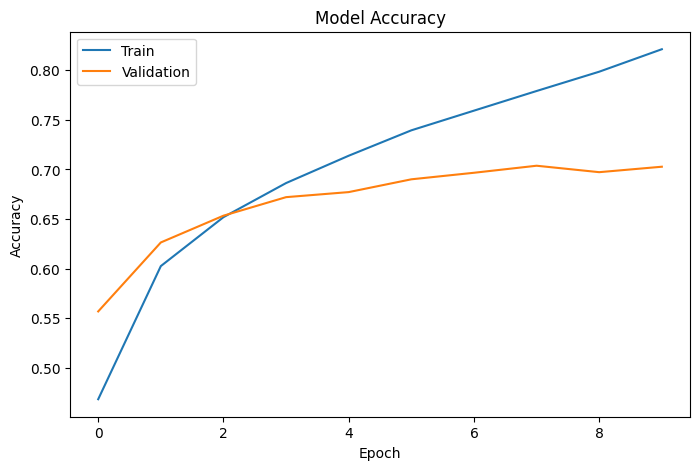

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

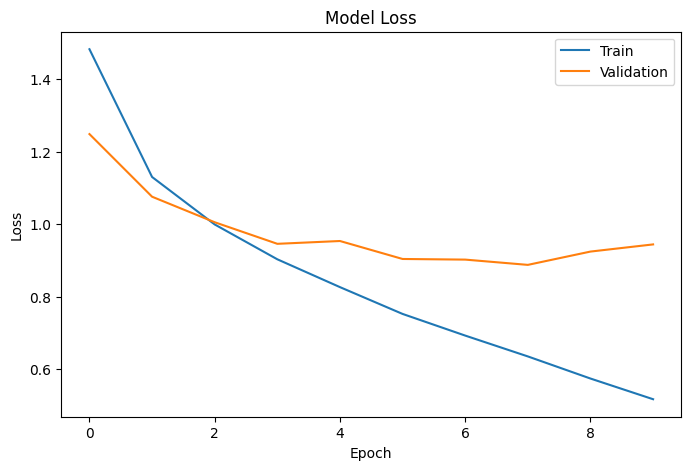

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
!pip install tensorflow-datasets -q

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

print("TFDS berhasil diimport")

TFDS berhasil diimport


In [ ]:
dataset, info = tfds.load(
    'cats_vs_dogs',
    with_info=True,
    as_supervised=True
)

print(info)

AttributeError: module 'tensorflow_datasets' has no attribute 'load'

In [ ]:
import tensorflow as tf
import numpy as np

x_train_resize = tf.image.resize(x_train, (96, 96))
x_test_resize = tf.image.resize(x_test, (96, 96))

print(x_train_resize.shape)
print(x_test_resize.shape)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

base_model = MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_tl.summary()

In [ ]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning siap dilatih")

In [ ]:
history_tl = model_tl.fit(
    x_train_resize,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=64
)

In [ ]:
test_loss_tl, test_acc_tl = model_tl.evaluate(
    x_test_resize,
    y_test
)

print("Transfer Learning Accuracy:", test_acc_tl)
print("Transfer Learning Loss:", test_loss_tl)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_tl.history['accuracy'])
plt.plot(history_tl.history['val_accuracy'])

plt.title('Transfer Learning Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_tl.history['loss'])
plt.plot(history_tl.history['val_loss'])

plt.title('Transfer Learning Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()